# 5. 회귀
## 5_1. 회귀 소개
- 회귀 분석 : 데이터 값이 일정한 값(ex. 평균)으로 돌아가려는 경향을 이용한 통계학 기법
- 회귀 : 여러 개의 독립변수와 한 개의 종속변수 간의 상관관계를 모델링하는 기법을 통칭
- 선형 회귀식 : Y = W1X1 + W2X2 + ... + WnXn
- 회귀 계수 : 위 선형 회귀식에서 W값 -> 최적의 회귀 계수를 찾아내는 것이 머신러닝 회귀 예측의 핵심.

### 1. 회귀의 종류
- 단일 / 다중 (독립변수의 개수에 따라)
- 선형 / 비선형 (회귀 계수의 결합에 따라)

### 2. 선형회귀
- 정의 : 실제 값과 예측 값의 차이(오류의 제곱 값)를 최소화하는 직선형 회귀선을 최적화하는 방식.
### 3. 선형회귀의 종류 (규제 방법에 따라)
- 규제 X -> '일반 선형 회귀'
- L2 규제(회귀 계수값을 작게) -> '릿지'
- L1 규제(예측 영향력 작은 피처 회귀 계수값 = 0) -> '라쏘'
- L2, L1 규제 -> '엘라스틱넷'
- 로지스틱 회귀

## 5_2. 단순 선형 회귀를 통한 회귀 이해
- 독립변수 1개, 종속변수 1개 (1차함수식 형태)
- 회귀 계수 : 기울기, 절편

### 1. 오류(잔차) 
- 실제 값과 회귀 모델의 차이에 따른 오류 값(이게 최소가 되는 최적의 회귀계수를 찾는 게 목표)
### 2. 잔차 구하기
#### 1) Mean Absolute Error : 절댓값을 취하여 모두 더한다.
#### 2) RSS, Residual Sum of Square : 오류 값의 제곱을 구하여 모두 더한다.
- Error의 제곱 = RSS
- 미분 등의 계산을 편리하게 할 수 있다.
- RSS(w0, w1) -> 비용함수, 손실함수. / 반환값이 더 이상 감소하지 않을 때까지 학습시킨다.

## 5_3. 비용 최소화하기 - 경사 하강법(Gradient Descent)
- 비용 함수 RSS를 최소화하는 방식을 직관적으로 제공
- 점진적/반복적 계산을 통해 W 파라미터 값을 업데이트하면서 오류 값이 최소가 되는 W 파라미터를 구하는 방식.
- 미분된 1차 함수의 기울기가 최소인 지점 = 비용함수 RSS가 최소인 지점

### 1. 실제값을 Y=4X+6 시뮬레이션하는 데이터 값 생성

- 경사 하강법 파이썬 코드 구현

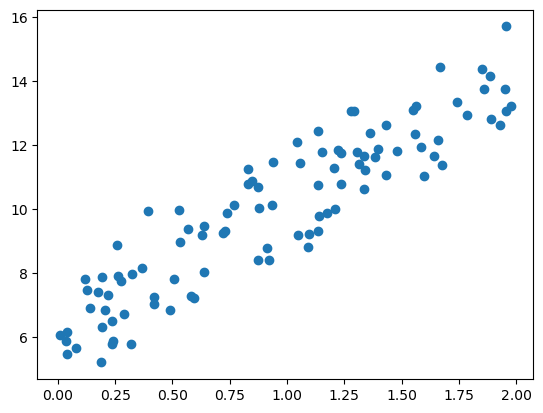

In [7]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(0)
# y = 4X + 6 식을 근사(w1=4, w0=6). random 값은 Noise를 위해 만듬
# 100개의 데이터 세트 생성
X = 2 * np.random.rand(100,1)
y = 6 +4 * X+ np.random.randn(100,1)

# X, y 데이터 셋 scatter plot으로 시각화
plt.scatter(X, y)

plt.show()

In [8]:
X.shape, y.shape

((100, 1), (100, 1))

### 2. w0과 w1의 값을 최소화 할 수 있도록 업데이트 수행하는 함수 생성
- 예측 배열 y_pred는 np.dot(X, w1.T) + w0 임 100개의 데이터 X(1,2,...,100)이 있다면 예측값은 w0 + X(1)w1 + X(2)w1 +..+ X(100)*w1이며, 이는 입력 배열 X와 w1 배열의 내적임.
- 새로운 w1과 w0를 update함

In [10]:
# w1 과 w0 를 업데이트 할 w1_update, w0_update를 반환. 
def get_weight_updates(w1, w0, X, y, learning_rate=0.01):
    N = len(y)
    # 먼저 w1_update, w0_update를 각각 w1, w0의 shape와 동일한 크기를 가진 0 값으로 초기화
    w1_update = np.zeros_like(w1)
    w0_update = np.zeros_like(w0)
    # 예측 배열 계산하고 예측과 실제 값의 차이 계산
    y_pred = np.dot(X, w1.T) + w0
    diff = y-y_pred
         
    # w0_update를 dot 행렬 연산으로 구하기 위해 모두 1값을 가진 행렬 생성 
    w0_factors = np.ones((N,1))

    # w1과 w0을 업데이트할 w1_update와 w0_update 계산
    w1_update = -(2/N)*learning_rate*(np.dot(X.T, diff))
    w0_update = -(2/N)*learning_rate*(np.dot(w0_factors.T, diff))    
    
    return w1_update, w0_update

In [11]:
w0 = np.zeros((1,1))
w1 = np.zeros((1,1))
y_pred = np.dot(X, w1.T) + w0
diff = y-y_pred
print(diff.shape)
w0_factors = np.ones((100,1))
w1_update = -(2/100)*0.01*(np.dot(X.T, diff))
w0_update = -(2/100)*0.01*(np.dot(w0_factors.T, diff))   
print(w1_update.shape, w0_update.shape)
w1, w0

(100, 1)
(1, 1) (1, 1)


(array([[0.]]), array([[0.]]))

### 3. 반복적으로 경사 하강법을 이용하여 get_weigth_updates()를 호출하여 w1과 w0를 업데이트 하는 함수 생성

In [13]:
# gradient_descent_steps() 함수 생성
# 입력 인자 iters로 주어진 횟수만큼 반복적으로 w1과 w0를 업데이트 적용함. 
def gradient_descent_steps(X, y, iters=10000):
    # w0와 w1을 모두 0으로 초기화. 
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))
    
    # 인자로 주어진 iters 만큼 반복적으로 get_weight_updates() 호출하여 w1, w0 업데이트 수행. 
    for ind in range(iters):
        w1_update, w0_update = get_weight_updates(w1, w0, X, y, learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update
              
    return w1, w0

### 4. 예측 오차 비용을 계산을 수행하는 함수 생성 및 경사 하강법 수행

In [15]:
# get_cost() 함수 정의 
def get_cost(y, y_pred):
    N = len(y) 
    cost = np.sum(np.square(y - y_pred))/N
    return cost
    
#gradient_descent_steps() 호출하여 w1, w0 구기기
w1, w0 = gradient_descent_steps(X, y, iters=1000)
print("w1:{0:.3f} w0:{1:.3f}".format(w1[0,0], w0[0,0]))
y_pred = w1[0,0] * X + w0
print('Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))

w1:4.022 w0:6.162
Gradient Descent Total Cost:0.9935


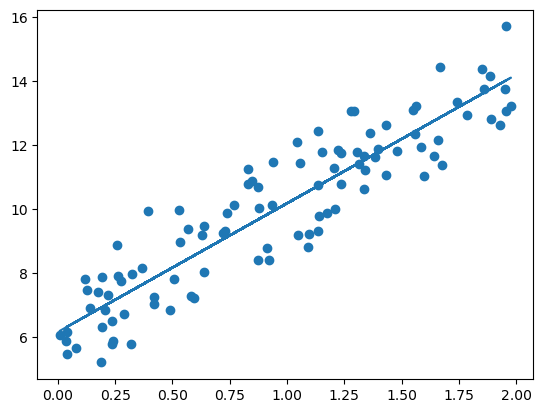

In [16]:
plt.scatter(X, y)
plt.plot(X,y_pred)

plt.show()

### 5. 미니 배치 확률적 경사 하강법을 이용한 최적 비용함수 도출

In [18]:
def stochastic_gradient_descent_steps(X, y, batch_size=10, iters=1000):
    w0 = np.zeros((1,1))
    w1 = np.zeros((1,1))
    prev_cost = 100000
    iter_index =0
    
    for ind in range(iters):
        np.random.seed(ind)
        # 전체 X, y 데이터에서 랜덤하게 batch_size만큼 데이터 추출하여 sample_X, sample_y로 저장
        stochastic_random_index = np.random.permutation(X.shape[0])
        sample_X = X[stochastic_random_index[0:batch_size]]
        sample_y = y[stochastic_random_index[0:batch_size]]
        # 랜덤하게 batch_size만큼 추출된 데이터 기반으로 w1_update, w0_update 계산 후 업데이트
        w1_update, w0_update = get_weight_updates(w1, w0, sample_X, sample_y, learning_rate=0.01)
        w1 = w1 - w1_update
        w0 = w0 - w0_update
    
    return w1, w0

In [19]:
# stochastic_gradient_descent_steps() 이용하여 w1, w0 및 예측 오류 비용 계산
w1, w0 = stochastic_gradient_descent_steps(X, y, iters=1000)
print("w1:",round(w1[0,0],3),"w0:",round(w0[0,0],3))
y_pred = w1[0,0] * X + w0
print('Stochastic Gradient Descent Total Cost:{0:.4f}'.format(get_cost(y, y_pred)))

w1: 4.028 w0: 6.156
Stochastic Gradient Descent Total Cost:0.9937


## 5_4. 사이킷런 LinearRegression을 이용한 ~~보스턴 주택 가격~~ 예측
## 5_4. 사이킷런 LinearRegression을 이용한 **'캘리포니아 주택 가격'** 예측
- 사이킷런의 버전이 높아 load_boston()이 작동하지 않아 대체 데이터셋 사용하여 실습 진행함.

### 사이킷런의 LinearRegression 클래스 - Ordinary Least Squares
- 예측값과 실제 값의 RSS를 최소화하여 OLS(Ordinart Least Squares) 추정 방식으로 구현한 클래스.
- 입력 파라미터 : fit_intercept(절편 값 계산 유무 설정), normalize(True 면 회귀 수행 전 입력 데이터 세트 정규화)
- 피처 간 상관관계가 높으면 오류에 민감해짐(다중공선성 문제)

### 회귀 평가 지표  
1. MAE : 실제 값과 예측값의 차이를 절댓값으로 변환해 평균냄
2. MSE : 실제 값과 예측값의 차이를 제곱해 평균냄
3. RMSE : MSE에 루트를 씌워 실제 오류 평균보다 MSE가 커지는 것을 방지
4. R2 : 분산 기반으로 예측 평가(1에 가까울수록 정확).

In [23]:
# 사이킷런의 버전이 높아 보스턴 주택 가격 데이터를 불러올 수 없어, 
#'!pip install scikit-learn==1.1.3' 코드를 통해 버전을 낮춰 봤지만, 여전히 오류가 발생

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats

# 데이터셋 로딩 함수 load_boston 대신에 fetch_califonia_housing 사용
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore') 
%matplotlib inline

# 캘리포니아 주택 데이터셋 로드
housing = fetch_california_housing()

# DataFrame으로 변환
housingDF = pd.DataFrame(housing.data, columns=housing.feature_names)

# target은 주택 가격 -> 'PRICE' 컬럼으로 추가
housingDF['PRICE'] = housing.target

print('California 주택 데이터셋 크기 :', housingDF.shape)
housingDF.head()


California 주택 데이터셋 크기 : (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


 - 각 컬럼별로 주택가격에 미치는 영향도를 조사

In [25]:
# 2개의 행과 4개의 열을 가진 subplots를 이용. axs는 4x2개의 ax를 가짐.
fig, axs = plt.subplots(figsize=(16,8) , ncols=4 , nrows=2)

#데이터셋 바꿨기 때문에 California 주택 데이터셋의 칼럼명으로 Im_features 값도 바꿔줌.
lm_features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms',
               'Population', 'AveOccup', 'Latitude', 'Longitude']

for i , feature in enumerate(lm_features):
    row = int(i/4)
    col = i%4
    # 시본의 regplot을 이용해 산점도와 선형 회귀 직선을 함께 표현
    sns.regplot(x=feature , y='PRICE',data=housingDF , ax=axs[row][col])

fig1 = plt.gcf()
fig1.savefig('p322_califonia.tif', format='tif', dpi=300, bbox_inches='tight')

- 학습과 테스트 데이터 세트로 분리하고 학습/예측/평가 수행

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 타겟,피처 분리
# bostonDF 대신 housingDF 씀
y_target = housingDF['PRICE']
X_data = housingDF.drop(['PRICE'],axis=1,inplace=False)

X_train , X_test , y_train , y_test = train_test_split(X_data , y_target ,test_size=0.3, random_state=156)

# Linear Regression OLS로 학습/예측/평가 수행. 
lr = LinearRegression()
lr.fit(X_train ,y_train )
y_preds = lr.predict(X_test)

# 평가 지표 계산
mse = mean_squared_error(y_test, y_preds)
rmse = np.sqrt(mse)

print('MSE : {0:.3f} , RMSE : {1:.3F}'.format(mse , rmse))
print('Variance score : {0:.3f}'.format(r2_score(y_test, y_preds)))

MSE : 0.543 , RMSE : 0.737
Variance score : 0.595


In [28]:
print('절편 값:',lr.intercept_)
print('회귀 계수값:', np.round(lr.coef_, 1))

절편 값: -37.2390530529416
회귀 계수값: [ 0.4  0.  -0.1  0.6 -0.  -0.  -0.4 -0.4]


In [29]:
# 회귀 계수를 큰 값 순으로 정렬하기 위해 Series로 생성. index가 칼럼명에 유의
coeff = pd.Series(data=np.round(lr.coef_, 1), index=X_data.columns )
coeff.sort_values(ascending=False)

AveBedrms     0.6
MedInc        0.4
HouseAge      0.0
Population   -0.0
AveOccup     -0.0
AveRooms     -0.1
Latitude     -0.4
Longitude    -0.4
dtype: float64

In [30]:
from sklearn.model_selection import cross_val_score

# bostonDF 대신 housingDF 씀
y_target = housingDF['PRICE']
X_data = housingDF.drop(['PRICE'],axis=1,inplace=False)
lr = LinearRegression()

# cross_val_score( )로 5 Fold 셋으로 MSE 를 구한 뒤 이를 기반으로 다시  RMSE 구함. 
neg_mse_scores = cross_val_score(lr, X_data, y_target, scoring="neg_mean_squared_error", cv = 5)
rmse_scores  = np.sqrt(-1 * neg_mse_scores)
avg_rmse = np.mean(rmse_scores)

# cross_val_score(scoring="neg_mean_squared_error")로 반환된 값은 모두 음수 
print(' 5 folds 의 개별 Negative MSE scores: ', np.round(neg_mse_scores, 2))
print(' 5 folds 의 개별 RMSE scores : ', np.round(rmse_scores, 2))
print(' 5 folds 의 평균 RMSE : {0:.3f} '.format(avg_rmse))

 5 folds 의 개별 Negative MSE scores:  [-0.48 -0.62 -0.65 -0.54 -0.49]
 5 folds 의 개별 RMSE scores :  [0.7  0.79 0.8  0.74 0.7 ]
 5 folds 의 평균 RMSE : 0.746 


## 5_5. 다항 회귀(Polynomial Regression)와 과(대)적합(오버피팅)/과소적합(언더피팅) 이해
### 1. 다항 회귀(Polynomial Regression)의 이해
- 회귀가 단항식이 아닌 '다항식'으로 표현되는 것.
- '선형' 회귀이다. 
#### 1) PolynomialFeatures 클래스로 다항식 변환

In [32]:
from sklearn.preprocessing import PolynomialFeatures
import numpy as np

# 다항식으로 변환한 단항식 생성, [[0,1],[2,3]]의 2X2 행렬 생성
X = np.arange(4).reshape(2,2)
print('일차 단항식 계수 feature:\n',X )

# degree = 2 인 2차 다항식으로 변환하기 위해 PolynomialFeatures를 이용하여 변환
poly = PolynomialFeatures(degree=2)
poly.fit(X)
poly_ftr = poly.transform(X)
print('변환된 2차 다항식 계수 feature:\n', poly_ftr)

일차 단항식 계수 feature:
 [[0 1]
 [2 3]]
변환된 2차 다항식 계수 feature:
 [[1. 0. 1. 0. 0. 1.]
 [1. 2. 3. 4. 6. 9.]]


#### 2) 3차 다항식 결정값을 구하는 함수 polynomial_func(X) 생성. 즉 회귀식은 결정값 y = 1+ 2x_1 + 3x_1^2 + 4x_2^3

In [34]:
def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3
    print(X[:, 0])
    print(X[:, 1])
    return y

X = np.arange(0,4).reshape(2,2)

print('일차 단항식 계수 feature: \n' ,X)
y = polynomial_func(X)
print('삼차 다항식 결정값: \n', y)

일차 단항식 계수 feature: 
 [[0 1]
 [2 3]]
[0 2]
[1 3]
삼차 다항식 결정값: 
 [  5 125]


#### 3) 3차 다항식 계수의 피처값과 3차 다항식 결정값으로 학습

In [36]:
# 3 차 다항식 변환 
poly_ftr = PolynomialFeatures(degree=3).fit_transform(X)
print('3차 다항식 계수 feature: \n',poly_ftr)

# Linear Regression에 3차 다항식 계수 feature와 3차 다항식 결정값으로 학습 후 회귀 계수 확인
model = LinearRegression()
model.fit(poly_ftr,y)
print('Polynomial 회귀 계수\n' , np.round(model.coef_, 2))
print('Polynomial 회귀 Shape :', model.coef_.shape)

3차 다항식 계수 feature: 
 [[ 1.  0.  1.  0.  0.  1.  0.  0.  0.  1.]
 [ 1.  2.  3.  4.  6.  9.  8. 12. 18. 27.]]
Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]
Polynomial 회귀 Shape : (10,)


#### 4) 사이킷런 파이프라인(Pipeline)을 이용하여 3차 다항회귀 학습
- 사이킷런의 Pipeline 객체는 Feature 엔지니어링 변환과 모델 학습/예측을 순차적으로 결합해줍니다.

In [38]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
import numpy as np

def polynomial_func(X):
    y = 1 + 2*X[:,0] + 3*X[:,0]**2 + 4*X[:,1]**3 
    return y

# Pipeline 객체로 Streamline 하게 Polynomial Feature변환과 Linear Regression을 연결
model = Pipeline([('poly', PolynomialFeatures(degree=3)),
                  ('linear', LinearRegression())])
X = np.arange(4).reshape(2,2)
y = polynomial_func(X)

model = model.fit(X, y)
print('Polynomial 회귀 계수\n', np.round(model.named_steps['linear'].coef_, 2))

Polynomial 회귀 계수
 [0.   0.18 0.18 0.36 0.54 0.72 0.72 1.08 1.62 2.34]


### 2. 다항 회귀를 이용한 과소적합 및 과적합 이해
#### 1) cosine 곡선에 약간의 Noise 변동값을 더하여 실제값 곡선을 만듬

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
%matplotlib inline

# 임의의 값으로 구성된 X값에 대해 코사인 변환 값을 반환.
def true_fun(X):
    return np.cos(1.5 * np.pi * X)

# X는 0부터 1까지 30개의 임의의 값을 순서대로 샘플링한 데이터입니다.
np.random.seed(0)
n_samples = 30
X = np.sort(np.random.rand(n_samples))

# y 값은 코사인 기반의 true_fun()에서 약간의 노이즈 변동 값을 더한 값입니다.
y = true_fun(X) + np.random.randn(n_samples) * 0.1

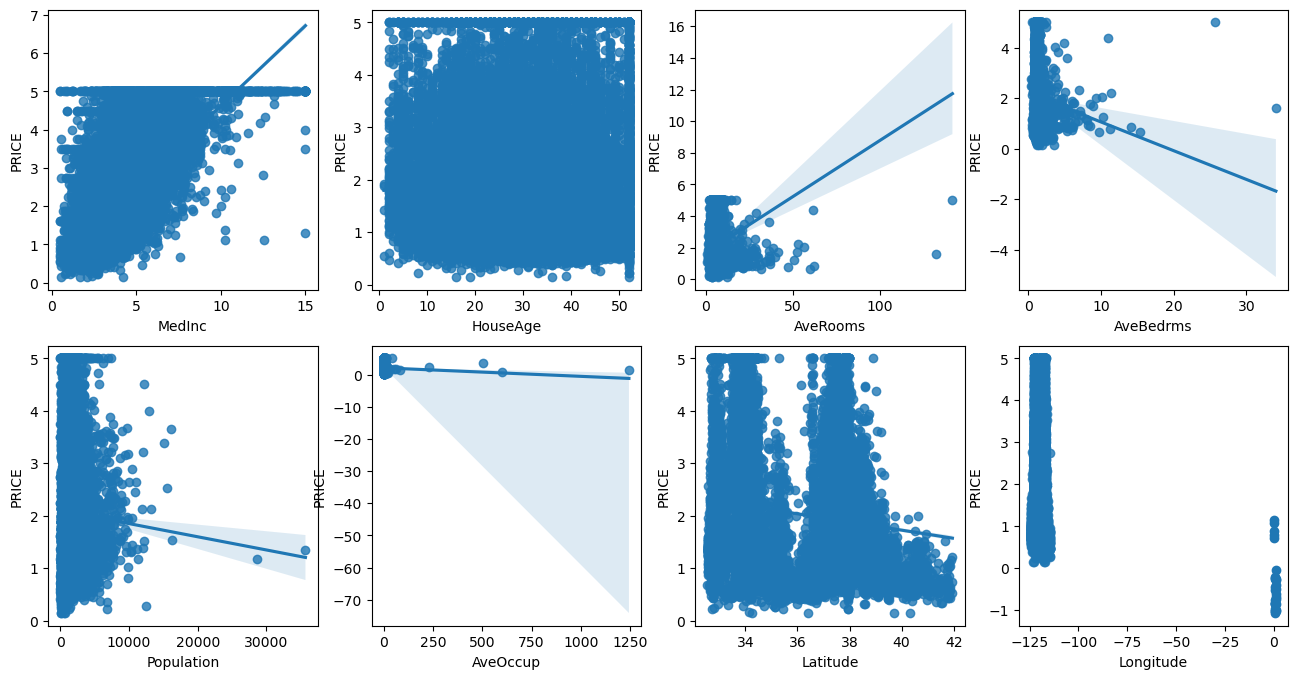

In [41]:
plt.scatter(X, y)
plt.show()


Degree 1 회귀 계수는 [-1.61] 입니다.
Degree 1 MSE 는 0.40772896250986834 입니다.

Degree 4 회귀 계수는 [  0.47 -17.79  23.59  -7.26] 입니다.
Degree 4 MSE 는 0.04320874987231747 입니다.

Degree 15 회귀 계수는 [-2.98295000e+03  1.03899930e+05 -1.87417069e+06  2.03717225e+07
 -1.44873988e+08  7.09318780e+08 -2.47066977e+09  6.24564048e+09
 -1.15677067e+10  1.56895696e+10 -1.54006776e+10  1.06457788e+10
 -4.91379977e+09  1.35920330e+09 -1.70381654e+08] 입니다.
Degree 15 MSE 는 182815433.47648773 입니다.


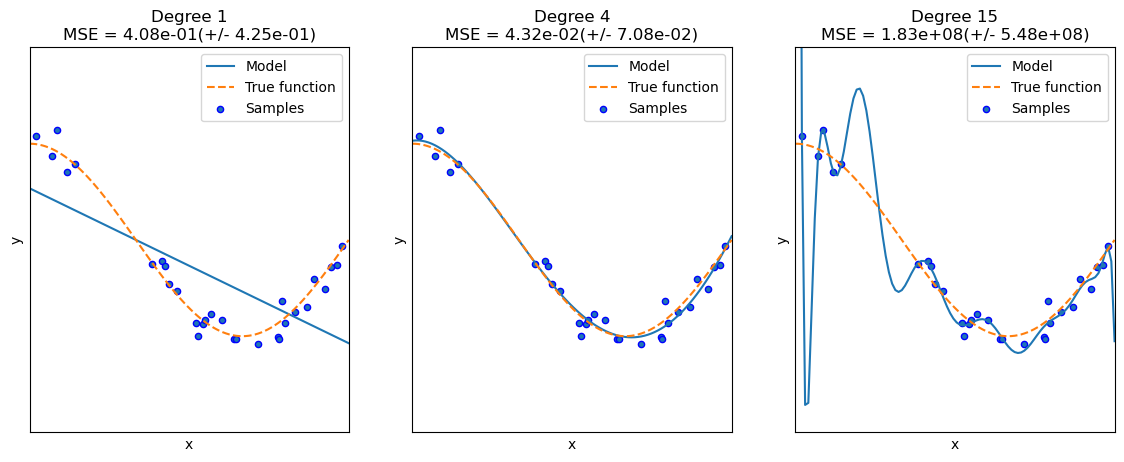

In [42]:
plt.figure(figsize=(14, 5))
degrees = [1, 4, 15]

# 다항 회귀의 차수(degree)를 1, 4, 15로 각각 변화시키면서 비교합니다.
for i in range(len(degrees)):
    ax = plt.subplot(1, len(degrees), i + 1)
    plt.setp(ax, xticks=(), yticks=())
    
    # 개별 degree별로 Polynomial 변환합니다.
    polynomial_features = PolynomialFeatures(degree=degrees[i], include_bias=False)
    linear_regression = LinearRegression()
    pipeline = Pipeline([("polynomial_features", polynomial_features),
                         ("linear_regression", linear_regression)])
    pipeline.fit(X.reshape(-1, 1), y)
    
    # 교차 검증으로 다항 회귀를 평가합니다.
    scores = cross_val_score(pipeline, X.reshape(-1, 1), y, scoring="neg_mean_squared_error", cv=10)
    # Pipeline을 구성하는 세부 객체를 접근하는 named_steps['객체명']을 이용해 회귀계수 추출
    coefficients = pipeline.named_steps['linear_regression'].coef_
    print('\nDegree {0} 회귀 계수는 {1} 입니다.'.format(degrees[i], np.round(coefficients, 2)))
    print('Degree {0} MSE 는 {1} 입니다.'.format(degrees[i], -1*np.mean(scores)))
          
    # 0 부터 1까지 테스트 데이터 세트를 100개로 나눠 예측을 수행합니다.
    # 테스트 데이터 세트에 회귀 예측을 수행하고 예측 곡선과 실제 곡선을 그려서 비교합니다.
    X_test = np.linspace(0, 1, 100)
    # 예측값 곡선
    plt.plot(X_test, pipeline.predict(X_test[:, np.newaxis]), label="Model")
    # 실제 값 곡선
    plt.plot(X_test, true_fun(X_test), '--', label="True function")
    plt.scatter(X, y, edgecolor='b', s=20, label="Samples")
    plt.xlabel("x"); plt.ylabel("y"); plt.xlim((0, 1)); plt.ylim((-2, 2)); plt.legend(loc="best")
    plt.title("Degree {}\nMSE = {:.2e}(+/- {:.2e})".format(degrees[i], -scores.mean(), scores.std()))
    
plt.show()

### 3. 편향(bias) - 분산(variance) 트레이드오프(trade off)
- 고편향성(High Bias) 모델 : 지나치게 한 방향으로 치우친 매우 단순화된 모델
- 고분산성(High Variance) 모델 : 지나치게 높은 변동성을 가진 매우 복잡한 모델
- 편향이 높으면 분산은 낮아지고(과소적합), 분산이 높으면 편향은 낮아지는(과적합) 경향을 보임.
- 골디락스 지점 : 편향을 낮추고 분산을 높이는 과정에서 전체 오류가 가장 낮아지는 지점. 이 지점을 지나서까지 계속 학습하면 다시 오류값이 증가.